# Trajectory KD vs WT

In [1]:
here::i_am("rna_atac/trajectory/v3/02_trajectory_KD_WT_comparison.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(BiocParallel))

suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 8

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
set.seed(42)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'results/rna_atac/trajectory/v3/rna_sce.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/trajectory/v3/KD_vs_WT/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

### Only continue with Trajectory 2 cell types, and assign all cells to that lineage

In [3]:
# Load meta
meta = fread(args$metadata)[day %in% c('D3.5', 'D4', 'D4.5', 'D5')] %>% # Remove D3 for KD vs WT comparison
    .[celltype_v2 %in% c('Primitive_Streak', 'Early_Mes_EOi','Posterior_Mes', 'Allantois_Precursor')]

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = F, cells = meta$cell)

In [5]:
# Only keep trajectory 2 cells
pseudotime = slingPseudotime(rna.sce$slingshot, na=T)[,2]
pseudotime = pseudotime[!is.na(pseudotime)]

In [6]:
meta2 = meta %>% .[match(names(pseudotime), cell)] %>% .[,pseudotime := pseudotime]

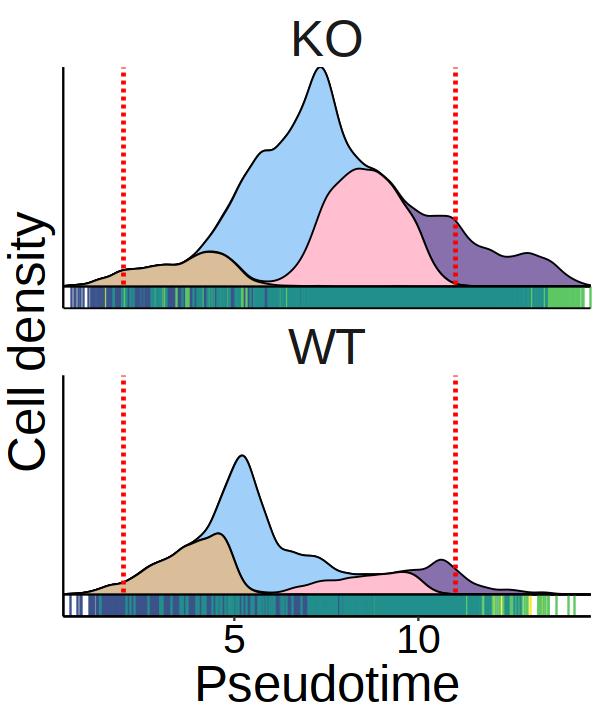

In [9]:
# facet_labels = c()
p1 = ggplot(meta2, aes(pseudotime, fill=celltype_v2)) + 
    # geom_histogram(binwidth=0.1, position='stack') + 
    geom_density(aes(y = after_stat(density * n/10)), position = 'stack', color = 'black', linewidth = 0.4, bw = 0.2) + 
    scale_colour_manual(values = opts$days.colors, name='day') + 
    scale_fill_manual(values = opts$celltype_v2.colors, name='Celltype') +
    scale_x_continuous(expand=c(0,0)) + 
    scale_y_continuous(expand=c(0,0)) + 
    geom_vline(xintercept = c(2, 11), color='red', linetype = 'dashed', linewidth = 1) + 
    xlab('Pseudotime') + ylab('Cell density') + 
    facet_wrap(~genotype, ncol = 1, 
               scales='fixed', 
               labeller = labeller(trajectory = c('Traj1' = 'Trajectory 1', 'Traj2' = 'Trajectory 2'))) + 
    theme_classic() + 
    theme(text = element_text(size=30),
          axis.text = element_text(color='black'),
          axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          strip.background = element_blank(),
          strip.text = element_text(size=30),
          legend.position='none')
p1_values = ggplot_build(p1)
p1 = p1 +    
    geom_segment(aes(x = pseudotime, xend = pseudotime, y = 0, yend = -max(p1_values$data[[1]]$ymax)/10, col=day)) + 
    geom_hline(yintercept=c(0,-max(p1_values$data[[1]]$ymax)/10), color='black')

options(repr.plot.width = 5, repr.plot.height=6)
p1

In [10]:
rna.sce = logNormCounts(rna.sce)

In [11]:
# Keep only cells within pseudotime window for analysis
tmp2 = as.data.table(pseudotime, keep.rownames=T)
pseudo_min = 2 # Previously had 4 -> 10
pseudo_max = 11

lineage_keep = names(pseudotime[pseudotime > pseudo_min & pseudotime <= pseudo_max])

within_pseudotime_cells = intersect(lineage_keep, meta$cell)

In [12]:
## Filter genes
#By minimum expression cdr
expression = data.table(gene = rownames(rna.sce),
                      KO_cdr = rowMeans(logcounts(rna.sce[,meta[cell %in% within_pseudotime_cells & genotype == 'KO', cell]])>0),
                       WT_cdr = rowMeans(logcounts(rna.sce[,meta[cell %in% within_pseudotime_cells & genotype == 'WT', cell]])>0))
genes_test = expression[KO_cdr > 0.15 | WT_cdr > 0.15, gene]
# By variance
args$features = 5e3 # get top 10k variable genes
decomp <- modelGeneVar(rna.sce[genes_test,within_pseudotime_cells], block=rna.sce[,within_pseudotime_cells]$sample) # [expression$gene,]
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>%  # Next try ordering by logFC instead of FDR
    as.data.table(., keep.rownames=T) %>% 
     head(n=args$features) %>% .$rn


# Currently seems to pick up many genes with very very low expression --> filter based on cellular detection rate

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [13]:
U <- model.matrix(~rna.sce[, within_pseudotime_cells]$replicate)

In [14]:
length(within_pseudotime_cells)

[1] 11231

In [15]:
summary(rownames(slingPseudotime(rna.sce$slingshot)[within_pseudotime_cells,]) ==
       colnames(counts(rna.sce[, within_pseudotime_cells])))

   Mode    TRUE 
logical   11231 

In [16]:
BPPARAM$workers = 12
sceGAM <- fitGAM(counts = counts(rna.sce[, within_pseudotime_cells]),
                 pseudotime = slingPseudotime(rna.sce$slingshot)[within_pseudotime_cells,2], # Only use traj 2 pseudotime
                 conditions = as.factor(rna.sce[,within_pseudotime_cells]$genotype), # KD vs WT comparison
                 cellWeights = rep(1, length(within_pseudotime_cells)), # All cells belong to the same trajectory
                 U = U, # Don't use replicates for test
                 nknots=8, 
                 genes = hvgs, # Only look at top 10k genes --> should probably reduce this further since it's already a ton, would improve FDR 
                 parallel = T,
                 BPPARAM=BPPARAM,
                 verbose=T)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.7 GiB”
Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



  |======================================================================| 100%



In [133]:
# saveRDS(sceGAM, file.path(args$outdir, 'sceGAM.rds'))

In [24]:
# sceGAM = readRDS(file.path(args$outdir, 'sceGAM.rds'))

In [17]:
# Test if l2fc should be changed around? Higher than 0.75 rather than lower
condRes <- conditionTest(sceGAM, l2fc = 0.5)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [18]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [19]:
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = rownames(sceGAM), nPoints = 100, tidy=TRUE))

In [20]:
genes_keep = condRes[sig==T, gene]
genes_label = condRes[sig==T, gene][1:20]

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')

cols <- trans(seq(0,1, length.out=20))
# col_fun = colorRamp2(seq(0, 100, 5), viridis::viridis(length(seq(0, 100, 5))))
col_fun = colorRamp2(seq(0, 100, 5), colorRampPalette(c("darkblue", "orange", "purple", 'darkorchid4'))(length(seq(0, 100, 5))))

ha = HeatmapAnnotation(pseudotime = 1:100,
                       col = list(pseudotime = col_fun))

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1_conditionWT', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage1_conditionKO', colnames(yhatSmooth_minmax))]

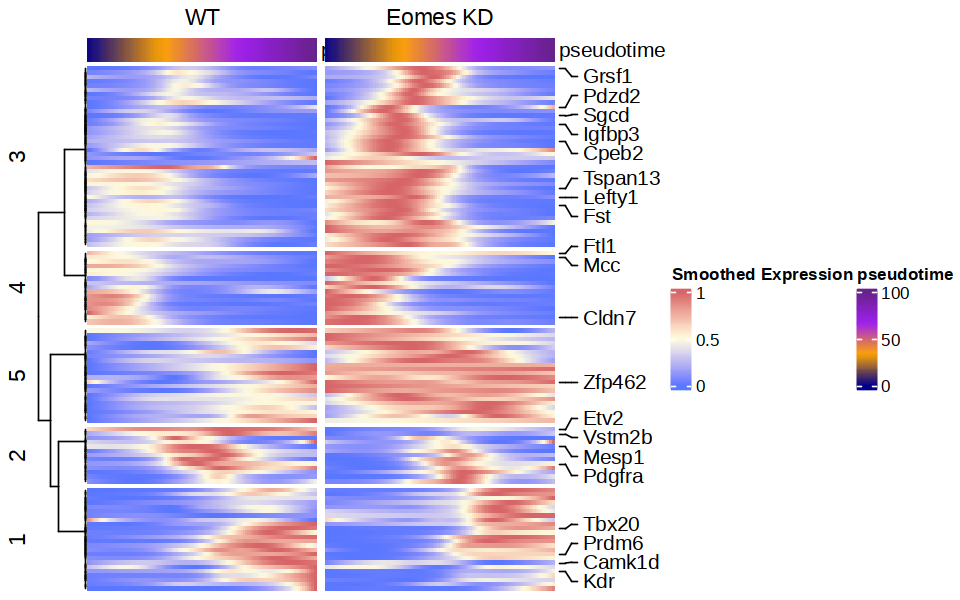

In [21]:
# Clustering
set.seed(42)
k = 5
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

ra = rowAnnotation(foo = anno_mark(at = match(genes_label, rownames(WT)), labels = genes_label))


hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'WT',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Eomes KD',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha,
                  right_annotation = ra)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

In [22]:
### Gene Ontology on the gene clusters
suppressPackageStartupMessages({
    library(biomaRt)
    library(limma)
    library(org.Mm.eg.db)
})

mapping = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.07052024.txt')

In [23]:
do_GO = function(genes){
    # Retrieve GO
    go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
        .[order(P.DE)] %>%
        .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
        .[P.DE < 0.1] %>% 
        .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
        .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
    # Add gene names to annotations
    GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
        as.data.table() %>% 
        .[, EVIDENCEALL := NULL] %>% 
        unique() %>% 
        merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
                  .[, entrezgene_id := as.character(entrezgene_id)],
              by.x = 'ENTREZID', by.y = 'entrezgene_id')
    # Add genes into GO list
    go = mclapply(1:nrow(go), function(x){ # nrow(go)
        GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
        genes_GO = intersect(GO_genes_tmp, genes)
        tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                                  N = length(intersect(rownames(rna.sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
        .[,enrichment := (DE/N)/(N/32285)] %>% 
        .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
    }, mc.cores = 10) %>% rbindlist()
    
    options(repr.plot.width=10, repr.plot.height=4)
    plot = go %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 0 & DE >= 3] %>% .[order(-enrichment)] %>% 
           # .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 3 & enrichment > 5] %>% .[order(FDR)] %>% 
            .[,Term := factor(Term, levels = rev(Term))] %>% 
            head(10)
    p = ggplot(plot, 
           aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
        geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
        geom_point() + 
        scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
        scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
        xlim(0, max(plot$enrichment)) + 
        theme_bw() + 
        theme(axis.text = element_text(size = 15, color = 'black'),
              axis.title.x = element_text(size = 20),
              axis.title.y = element_blank())
    return(list(go, p))
}

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0042074,cell migration involved in gastrulation,BP,17,3,4.887644e-06,0.002785866,100.00000,"Lefty1, Nodal, T"
GO:0001829,trophectodermal cell differentiation,BP,25,3,1.634679e-05,0.005935962,100.00000,"Cdh1, Eomes, Nodal"
GO:0032925,regulation of activin receptor signaling pathway,BP,25,3,1.845302e-05,0.006596091,100.00000,"Lefty1, Fst, Nodal"
GO:0060795,cell fate commitment involved in formation of primary germ layer,BP,32,3,3.490708e-05,0.009982115,94.58496,"Eomes, Nodal, Wnt3a"
GO:0032924,activin receptor signaling pathway,BP,42,3,8.552078e-05,0.017949164,54.90646,"Lefty1, Fst, Nodal"
GO:0010862,positive regulation of pathway-restricted SMAD protein phosphorylation,BP,51,3,1.344961e-04,0.025428655,37.23760,"Lefty1, Nodal, Lefty2"
GO:0001707,mesoderm formation,BP,67,4,9.606089e-06,0.003995609,28.76810,"Eomes, Nodal, T, Wnt3a"
GO:0001825,blastocyst formation,BP,59,3,2.202791e-04,0.034281119,27.82390,"Cdh1, Eomes, Nodal"
GO:0048332,mesoderm morphogenesis,BP,71,4,1.210576e-05,0.004615725,25.61793,"Eomes, Nodal, T, Wnt3a"


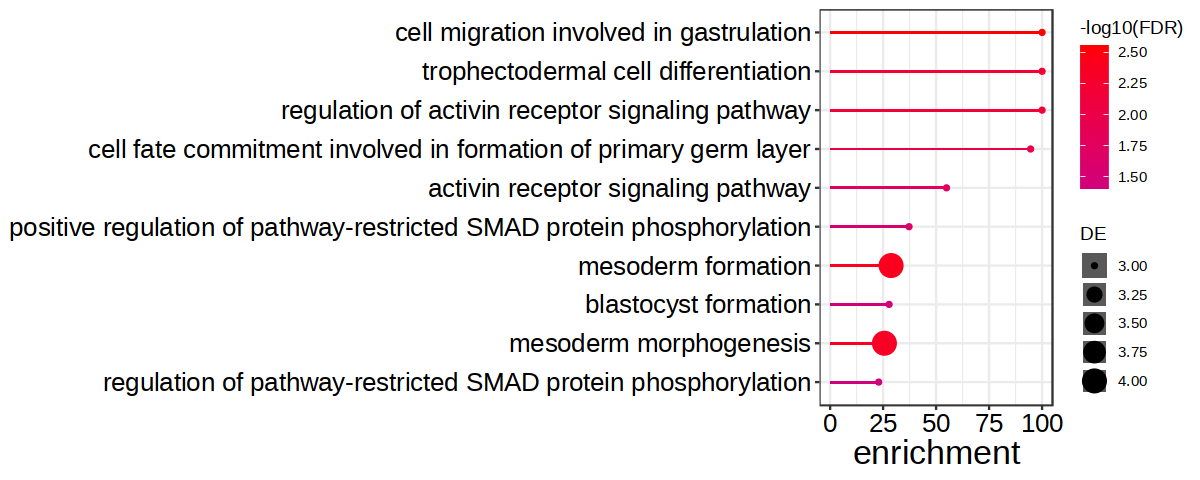

In [31]:
genes = names(group)[group %in% c(3, 4)]
tmp = do_GO(genes)
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 0 & DE >= 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

'select()' returned 1:many mapping between keys and columns

Warning message in max(plot$enrichment):
“no non-missing arguments to max; returning -Inf”


GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


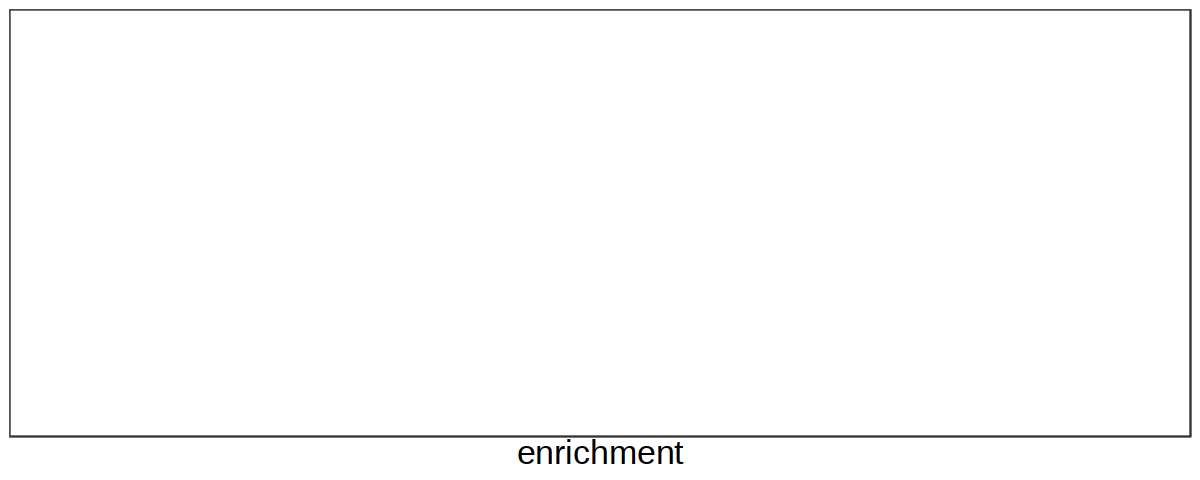

In [32]:
genes = names(group)[group %in% c(5)]
tmp = do_GO(genes)
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 0 & DE >= 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0030513,positive regulation of BMP signaling pathway,BP,39,3,4.768736e-06,1.886262e-03,63.67850,"Gata4, Kdr, Tbx20"
GO:0001569,branching involved in blood vessel morphogenesis,BP,45,3,6.334496e-06,2.264285e-03,47.82963,"Kdr, Nrp1, Tbx20"
GO:0051893,regulation of focal adhesion assembly,BP,64,3,1.841356e-05,4.898221e-03,23.64624,"Kdr, Nrp1, Dlc1"
GO:0090109,regulation of cell-substrate junction assembly,BP,64,3,1.841356e-05,4.898221e-03,23.64624,"Kdr, Nrp1, Dlc1"
GO:0150116,regulation of cell-substrate junction organization,BP,69,3,2.309474e-05,5.936386e-03,20.34342,"Kdr, Nrp1, Dlc1"
GO:0001570,vasculogenesis,BP,96,5,1.320247e-08,1.420699e-05,17.51573,"Gata4, Kdr, Nrp1, Itgb8, Tbx20"
GO:0060411,cardiac septum morphogenesis,BP,79,3,4.317096e-05,9.060754e-03,15.51915,"Gata4, Nrp1, Tbx20"
GO:0003208,cardiac ventricle morphogenesis,BP,81,3,3.876961e-05,8.528195e-03,14.76223,"Gata4, Tpm1, Tbx20"
GO:0034103,regulation of tissue remodeling,BP,84,3,4.317096e-05,9.060754e-03,13.72662,"Dlk1, Gata4, Sfrp1"


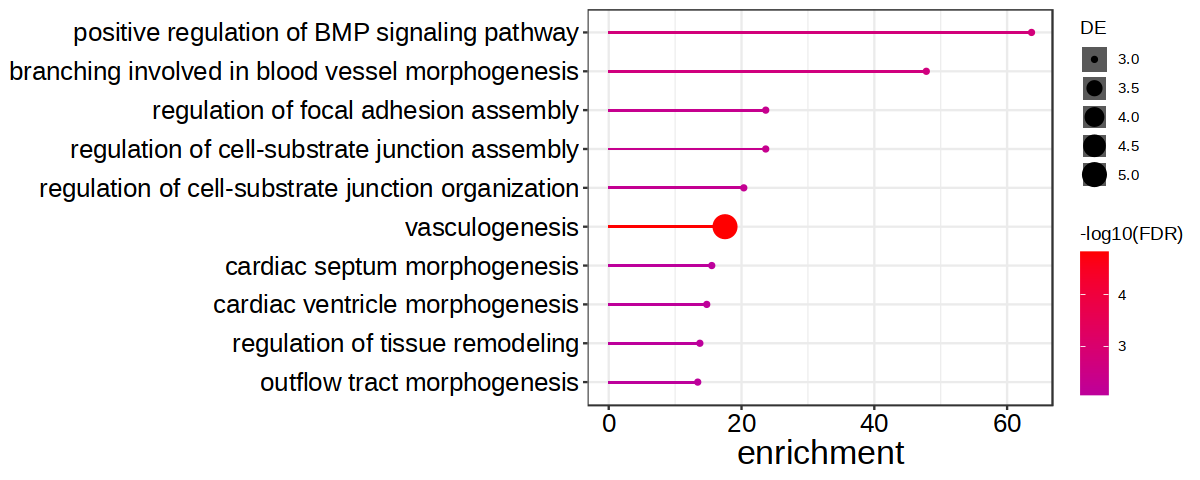

In [33]:
genes = names(group)[group %in% c(1)]
tmp = do_GO(genes)
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 0 & DE >= 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0030858,positive regulation of epithelial cell differentiation,BP,58,3,2.403206e-06,0.0021991255,28.791617,"Etv2, Lhx1, Mesp1"
GO:0001656,metanephros development,BP,90,3,7.663464e-06,0.0053126384,11.957407,"Lhx1, Pdgfra, Robo2"
GO:0001657,ureteric bud development,BP,107,4,1.087519e-07,0.0003874503,11.279588,"Lhx1, Robo2, Hs3st3b1, Bmper"
GO:0072163,mesonephric epithelium development,BP,107,4,1.215728e-07,0.0003874503,11.279588,"Lhx1, Robo2, Hs3st3b1, Bmper"
GO:0072164,mesonephric tubule development,BP,107,4,1.215728e-07,0.0003874503,11.279588,"Lhx1, Robo2, Hs3st3b1, Bmper"
GO:0001823,mesonephros development,BP,110,4,1.354899e-07,0.0003874503,10.672727,"Lhx1, Robo2, Hs3st3b1, Bmper"
GO:0001704,formation of primary germ layer,BP,105,3,1.212387e-05,0.0074961563,8.785034,"Etv2, Lhx1, Mesp1"
GO:0001708,cell fate specification,BP,112,3,1.508135e-05,0.0084848363,7.721221,"Etv2, Mesp1, Tenm4"
GO:0007498,mesoderm development,BP,123,3,1.847955e-05,0.0094029296,6.401943,"Etv2, Lhx1, Mesp1"


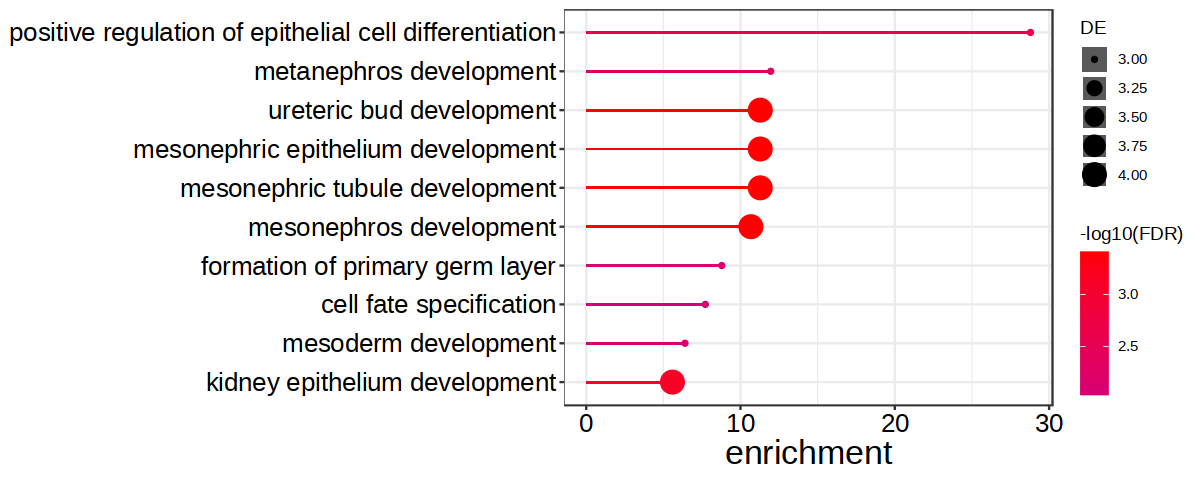

In [34]:
genes = names(group)[group %in% c(2)]
tmp = do_GO(genes)
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 0 & DE >= 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

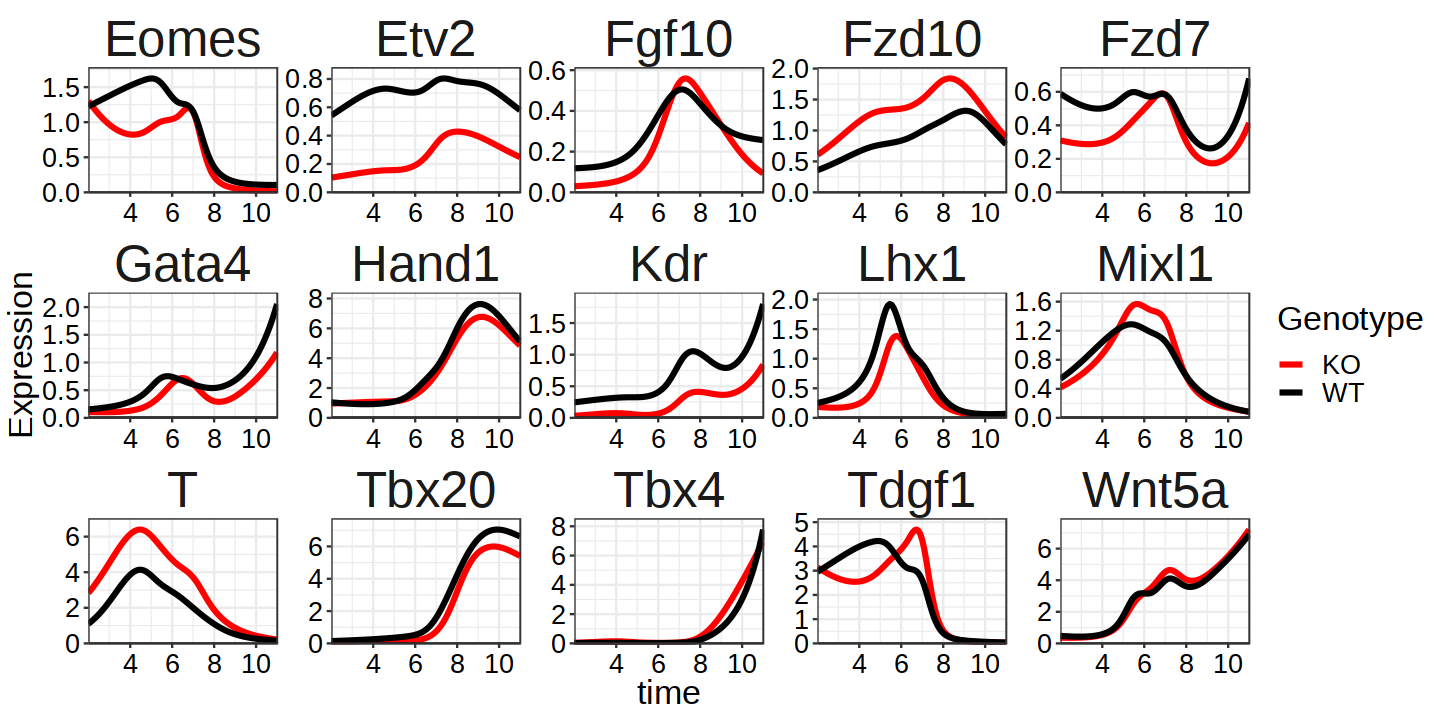

In [37]:
input_gene = c('Gata4', 'Etv2', 'Eomes', 'Kdr', 'Tbx20', 'Mixl1', 'Lhx1', 'Hand1', 'Tbx4', 'Fzd7', 'Fzd10', 'Fgf10', 'Tdgf1', 'Wnt5a', 'Fgf18', 'T')
input_gene = intersect(input_gene, rownames(sceGAM))
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = input_gene, nPoints = 100, tidy = TRUE))
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(yhatSmooth, aes(time, yhat, color = condition)) + 
    geom_line(linewidth = 1.3) + 
    scale_color_manual(values=c('KO'='red', 'WT'='black'), name='Genotype') + 
    scale_x_continuous(expand=c(0.0001,0, 0.001, 0), breaks=c(seq(4, 50, 2))) + 
    scale_y_continuous(expand=c(0,0, 0.1, 0)) + 
    geom_hline(yintercept=0) +
    facet_wrap(~gene, ncol = 5, scales = 'free') + 
    ylab('Expression') + 
    theme_bw() + 
    theme(strip.background = element_blank(),
          text = element_text(size=20),
          strip.text = element_text(size = 30),
          plot.title = element_text(size = 30),
          axis.text = element_text(color='black'),
          axis.text.x = element_text(angle=0, hjust=0.5, vjust=0.5))

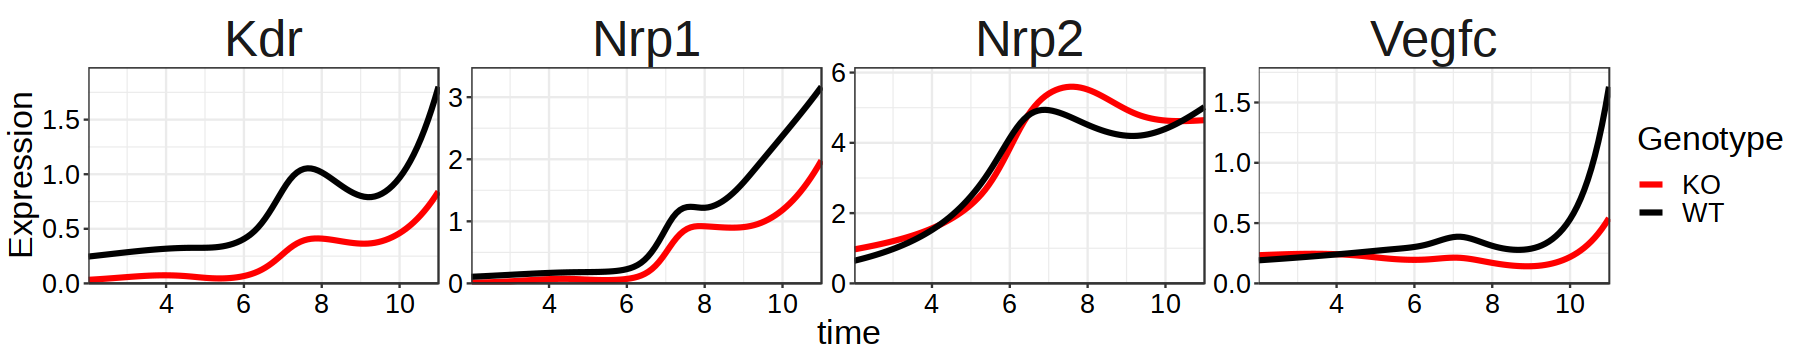

In [47]:
input_gene = c('Vegfc', 'Kdr', 'Flt1', 'Nrp1', 'Nrp2', 'Flt4')
input_gene = intersect(input_gene, rownames(sceGAM))
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = input_gene, nPoints = 100, tidy = TRUE))
options(repr.plot.width = 15, repr.plot.height = 3)
ggplot(yhatSmooth, aes(time, yhat, color = condition)) + 
    geom_line(linewidth = 1.3) + 
    scale_color_manual(values=c('KO'='red', 'WT'='black'), name='Genotype') + 
    scale_x_continuous(expand=c(0.0001,0, 0.001, 0), breaks=c(seq(4, 50, 2))) + 
    scale_y_continuous(expand=c(0,0, 0.1, 0)) + 
    geom_hline(yintercept=0) +
    facet_wrap(~gene, ncol = 5, scales = 'free') + 
    ylab('Expression') + 
    theme_bw() + 
    theme(strip.background = element_blank(),
          text = element_text(size=20),
          strip.text = element_text(size = 30),
          plot.title = element_text(size = 30),
          axis.text = element_text(color='black'),
          axis.text.x = element_text(angle=0, hjust=0.5, vjust=0.5))

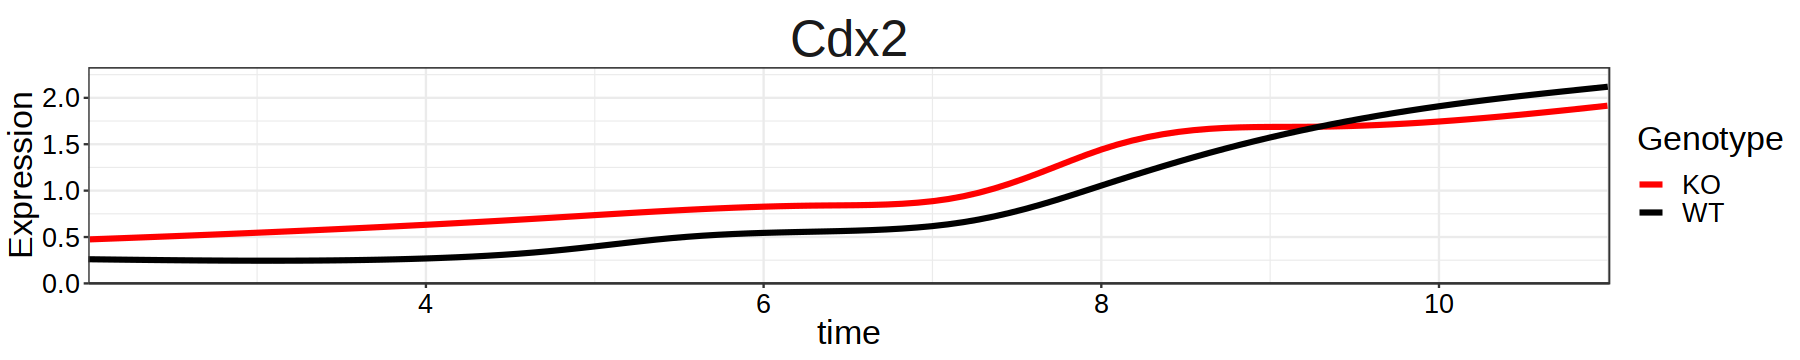

In [52]:
input_gene = c('Cdx2', 'Cdx4', 'Hoxa10', 'Hoxa11')
input_gene = intersect(input_gene, rownames(sceGAM))
yhatSmooth <- as.data.table(predictSmooth(sceGAM, gene = input_gene, nPoints = 100, tidy = TRUE))
options(repr.plot.width = 15, repr.plot.height = 3)
ggplot(yhatSmooth, aes(time, yhat, color = condition)) + 
    geom_line(linewidth = 1.3) + 
    scale_color_manual(values=c('KO'='red', 'WT'='black'), name='Genotype') + 
    scale_x_continuous(expand=c(0.0001,0, 0.001, 0), breaks=c(seq(4, 50, 2))) + 
    scale_y_continuous(expand=c(0,0, 0.1, 0)) + 
    geom_hline(yintercept=0) +
    facet_wrap(~gene, ncol = 5, scales = 'free') + 
    ylab('Expression') + 
    theme_bw() + 
    theme(strip.background = element_blank(),
          text = element_text(size=20),
          strip.text = element_text(size = 30),
          plot.title = element_text(size = 30),
          axis.text = element_text(color='black'),
          axis.text.x = element_text(angle=0, hjust=0.5, vjust=0.5))

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


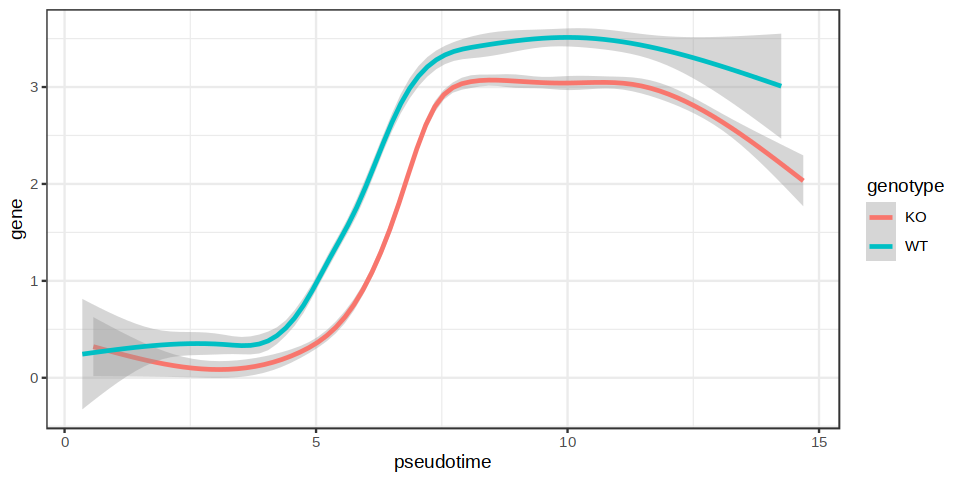

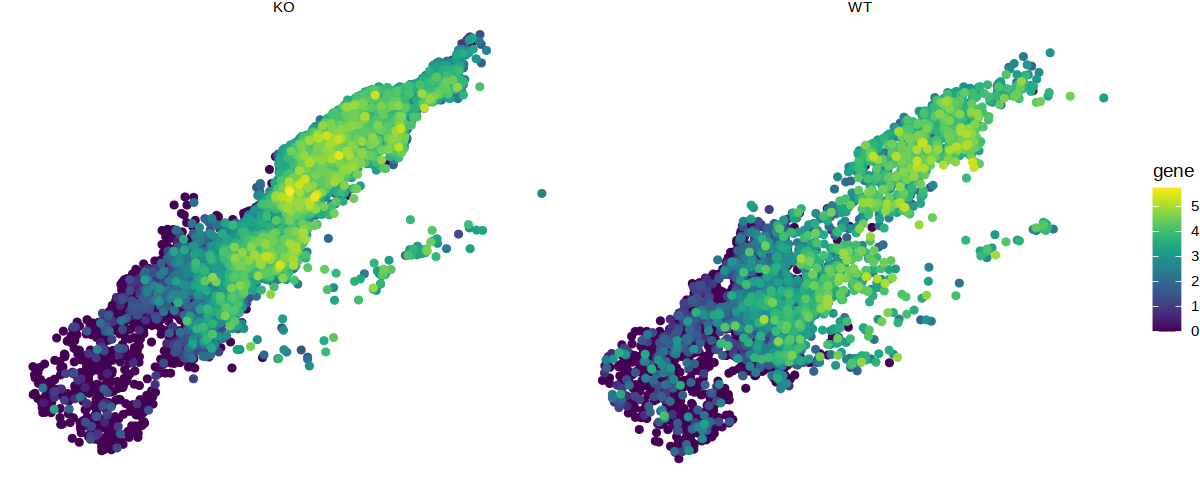

In [ ]:
gene = 'Prdm6'
meta3 = meta2 %>% copy() %>%
    .[, gene := as.vector(logcounts(rna.sce[gene,meta2$cell]))] %>% 
    .[order(gene)]

options(repr.plot.width = 8, repr.plot.height = 4)
ggplot(meta3, aes(pseudotime, gene, color = genotype)) + 
    geom_smooth() + 
    theme_bw()

options(repr.plot.width = 10, repr.plot.height = 4)
ggplot(meta3, aes(UMAP1, UMAP2, color = gene)) +
    geom_point() +
    viridis::scale_color_viridis() +
    coord_fixed() + 
    facet_wrap(~genotype) + 
    theme_void()